# Analisis de Indicadores PND 2022-2026 - Salud
## Fuente: DANE Estadisticas Vitales

| Indicador | Fuente | Formula |
|---|---|---|
| 1. Razon Mortalidad Materna | Defunciones cuadro11 + Nacimientos cuadro1 | Muertes 078 / NV x 100.000 |
| 2. Mortalidad Menores de 5 | Defunciones cuadro11 | Suma grupos edad <1 + 1-4 |
| 3. Fecundidad 15-19 | Nacimientos cuadro1 | Nacimientos madres 15-19 |
| 4. Fecundidad 10-14 | Nacimientos cuadro1 | Nacimientos ninas 10-14 |

---
## 1. Configuracion y Carga

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Colores estilo Sinergia DNP
COLOR_AZUL    = '#1A5276'
COLOR_AZUL2   = '#2E86C1'
COLOR_ROJO    = '#C0392B'
COLOR_VERDE   = '#1E8449'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 120
})

# Meta PND 2026
META_RMM = 51.4

os.makedirs('data/indicadores', exist_ok=True)
print('Configuracion lista.')

Configuracion lista.


In [3]:
# Cargar Cuadro 5 de defunciones (contiene causas de muerte)
ruta_cuadro5 = 'data/medio_proceso/defunciones_todos_los_cuadro5.csv'

if os.path.exists(ruta_cuadro5):
    df_defunciones = pd.read_csv(ruta_cuadro5)
    print(f"✅ Datos de defunciones cargados:")
    print(f"   • Filas: {len(df_defunciones):,}")
    print(f"   • Columnas: {len(df_defunciones.columns)}")
    print(f"   • Años: {sorted(df_defunciones['año'].unique())}")
else:
    print(f"❌ Archivo no encontrado: {ruta_cuadro5}")
    print("Buscando archivo en otra ubicación...")
    
    # Buscar alternativas
    archivos = glob.glob("**/defunciones*todos*los*cuadro5*.csv", recursive=True)
    if archivos:
        df_defunciones = pd.read_csv(archivos[0])
        print(f"✅ Encontrado: {archivos[0]}")
    else:
        print("❌ No se encontró el archivo de defunciones")

✅ Datos de defunciones cargados:
   • Filas: 131,744
   • Columnas: 41
   • Años: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [4]:
# Cargar Cuadro 1 de nacimientos (total nacional)
ruta_nacimientos = 'data/medio_proceso/nacimientos_todos_los_cuadro1.csv'

if os.path.exists(ruta_nacimientos):
    df_nacimientos = pd.read_csv(ruta_nacimientos)
    print(f"✅ Datos de nacimientos cargados:")
    print(f"   • Filas: {len(df_nacimientos):,}")
    print(f"   • Columnas: {len(df_nacimientos.columns)}")
    print(f"   • Años: {sorted(df_nacimientos['año'].unique())}")
else:
    print(f"❌ Archivo no encontrado: {ruta_nacimientos}")
    
    # Buscar alternativas
    archivos = glob.glob("**/nacimientos*todos*los*cuadro1*.csv", recursive=True)
    if archivos:
        df_nacimientos = pd.read_csv(archivos[0])
        print(f"✅ Encontrado: {archivos[0]}")
    else:
        print("❌ No se encontró el archivo de nacimientos")

✅ Datos de nacimientos cargados:
   • Filas: 56
   • Columnas: 22
   • Años: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [5]:
# Ver columnas disponibles en defunciones
print("📊 COLUMNAS EN DEFUNCIONES (Cuadro 5):")
print(df_defunciones.columns.tolist()[:20])  # Primeras 20
print(f"\nTotal columnas: {len(df_defunciones.columns)}")

# Ver una muestra de los datos
print("\n📝 MUESTRA DE DEFUNCIONES (primeras 5 filas):")
print(df_defunciones[['año', 'columna', 'columna_1', 'columna_2', 'columna_4', 'columna_5']].head(10))

# Ver columnas en nacimientos
print("\n" + "="*60)
print("📊 COLUMNAS EN NACIMIENTOS (Cuadro 1):")
print(df_nacimientos.columns.tolist()[:20])  # Primeras 20
print(f"\nTotal columnas: {len(df_nacimientos.columns)}")

📊 COLUMNAS EN DEFUNCIONES (Cuadro 5):
['columna', 'columna_1', 'CUADRO 5 - Defunciones por grupos de edad y sexo, según departamento, municipio de residencia y grupos de causas de defunción  (Lista de causas agrupadas 6/67 CIE-10 de OPS)', 'columna_2', 'columna_3', 'columna_4', 'columna_5', 'columna_6', 'columna_7', 'columna_8', 'columna_9', 'columna_10', 'columna_11', 'columna_12', 'columna_13', 'columna_14', 'columna_15', 'columna_16', 'columna_17', 'columna_18']

Total columnas: 41

📝 MUESTRA DE DEFUNCIONES (primeras 5 filas):
    año  columna  columna_1 columna_2  columna_4 columna_5
0  2022      NaN        NaN       NaN        NaN       NaN
1  2022      NaN        NaN       NaN  Municipio       NaN
2  2022      NaN        NaN       NaN      Total     Total
3  2022      NaN        NaN       NaN        NaN   Hombres
4  2022      3.0     3000.0       NaN     287251    159171
5  2022      3.0     3000.0       NaN       3704      2272
6  2022      3.0     3000.0       NaN       1170   

---
## 2. Indicador 1: Razon de Mortalidad Materna
**Numerador:** Causa `078 Embarazo, parto y puerperio` — Total Nacional por ano  
**Denominador:** Total nacidos vivos — Total Nacional por ano  
**Meta PND 2026:** 51.4 por 100.000 NV

In [6]:
# Buscar el código 078 (Embarazo, parto y puerperio) en los datos
print("🔍 BUSCANDO CAUSA 078 - Embarazo, parto y puerperio\n")

# Identificar qué columnas tienen texto de causas
columnas_texto = df_defunciones.select_dtypes(include=['object']).columns
print(f"Columnas de texto disponibles: {columnas_texto.tolist()}")

# Buscar en cada columna de texto
for col in columnas_texto[:5]:  # Probar primeras 5 columnas de texto
    print(f"\nBuscando en columna '{col}':")
    muestras = df_defunciones[col].dropna().head(10).tolist()
    print(f"  Muestras: {muestras[:5]}")
    
    # Buscar código 078
    mascara = df_defunciones[col].astype(str).str.contains('078', na=False)
    if mascara.any():
        print(f"  ✅ ¡ENCONTRADO! {mascara.sum()} filas con código 078 en '{col}'")
        break

# Buscar también por texto
print("\n🔍 Buscando por texto 'embarazo'...")
for col in columnas_texto[:5]:
    mascara = df_defunciones[col].astype(str).str.contains('embarazo|parto|puerperio', case=False, na=False)
    if mascara.any():
        print(f"  ✅ Encontrado en '{col}': {mascara.sum()} filas")

🔍 BUSCANDO CAUSA 078 - Embarazo, parto y puerperio

Columnas de texto disponibles: ['CUADRO 5 - Defunciones por grupos de edad y sexo, según departamento, municipio de residencia y grupos de causas de defunción  (Lista de causas agrupadas 6/67 CIE-10 de OPS)', 'columna_2', 'columna_3', 'columna_4', 'columna_5', 'columna_6', 'columna_7', 'columna_8', 'columna_9', 'columna_10', 'columna_11', 'columna_12', 'columna_13', 'columna_14', 'columna_15', 'columna_16', 'columna_17', 'columna_18', 'columna_19', 'columna_20', 'columna_21', 'columna_22', 'columna_23', 'columna_24', 'columna_25', 'columna_26', 'columna_27', 'columna_28', 'columna_29', 'columna_30', 'columna_31', 'columna_32', 'columna_33', 'columna_34', 'tipo', 'hoja_origen', 'cuadro', 'CUADRO 5 - Defunciones por grupo de edad y sexo, según departamento, municipio de residencia y grupo de causas de defunción  (Lista de causas agrupadas 6/67 CIE-10 de OPS)']

Buscando en columna 'CUADRO 5 - Defunciones por grupos de edad y sexo, según

In [7]:
# Primero, identificar las columnas de valores numéricos
print("🔍 IDENTIFICANDO COLUMNAS NUMÉRICAS")
columnas_numericas = df_defunciones.select_dtypes(include=[np.number]).columns
print(f"Columnas numéricas: {columnas_numericas.tolist()}")

# Identificar la columna que contiene las causas
columna_causa = None
for col in df_defunciones.columns:
    if df_defunciones[col].astype(str).str.contains('078', na=False).any():
        columna_causa = col
        print(f"\n✅ Columna de causas identificada: '{columna_causa}'")
        break

if columna_causa:
    # Extraer muertes maternas
    muertes_maternas = df_defunciones[
        df_defunciones[columna_causa].astype(str).str.contains('078', na=False)
    ].copy()
    
    print(f"\n📊 Total registros con causa 078: {len(muertes_maternas)}")
    
    # Ver qué columnas numéricas tienen datos
    print("\nColumnas numéricas con valores en estos registros:")
    for col_num in columnas_numericas[:10]:  # Primeras 10 columnas numéricas
        total = muertes_maternas[col_num].sum()
        if total > 0:
            print(f"  • {col_num}: {total:,.0f}")
    
    # Asumiendo que la columna de total es una de las primeras numéricas
    # Ajusta según lo que veas arriba
    columna_total = columnas_numericas[0]  # Cambia esto según lo que veas
    
    # Agrupar por año
    muertes_por_año = muertes_maternas.groupby('año')[columna_total].sum().reset_index()
    muertes_por_año.columns = ['año', 'muertes_maternas']
    
    print("\n📈 Muertes maternas por año:")
    print(muertes_por_año)
else:
    print("❌ No se encontró la columna con código 078")

🔍 IDENTIFICANDO COLUMNAS NUMÉRICAS
Columnas numéricas: ['columna', 'columna_1', 'año']

✅ Columna de causas identificada: 'columna_1'

📊 Total registros con causa 078: 528

Columnas numéricas con valores en estos registros:
  • columna: 13,290
  • columna_1: 13,407,756
  • año: 1,068,354

📈 Muertes maternas por año:
    año  muertes_maternas
0  2022            3630.0
1  2023            3519.0
2  2024            3414.0
3  2025            2727.0


In [8]:
# CORREGIR: Extraer correctamente los valores de nacimientos
print("🔍 CORRIGIENDO EXTRACCIÓN DE NACIMIENTOS\n")

# Volver a cargar los datos de nacimientos con la estructura correcta
nacimientos_total = df_nacimientos[
    df_nacimientos.iloc[:, 0].astype(str).str.contains('Total Nacional', na=False)
].copy()

if len(nacimientos_total) > 0:
    print(f"✅ Encontrados {len(nacimientos_total)} registros de Total Nacional")
    
    # Mostrar todas las columnas para identificar los valores reales
    print("\n📋 TODAS LAS COLUMNAS CON VALORES:")
    for col in nacimientos_total.columns:
        if col not in ['año', 'tipo', 'hoja_origen', 'cuadro']:
            valores = nacimientos_total[col].values
            if pd.api.types.is_numeric_dtype(nacimientos_total[col]):
                print(f"  • {col}: {valores}")
    
    # La columna 'columna' parece tener el total general
    # Pero necesitamos los valores reales, no el año
    nacimientos_corregidos = []
    
    for _, row in nacimientos_total.iterrows():
        año_real = row['año']
        
        # Buscar la columna que contiene los nacimientos totales
        # Según la muestra, 'columna' tiene valores como 46942, 43744, 243870
        if 'columna' in nacimientos_total.columns:
            total_nac = row['columna']
            nacimientos_corregidos.append({
                'año': año_real,
                'total_nacimientos': total_nac
            })
    
    # Crear DataFrame corregido
    nacimientos_corregidos_df = pd.DataFrame(nacimientos_corregidos)
    
    print("\n📊 NACIMIENTOS CORREGIDOS:")
    print(nacimientos_corregidos_df.to_string(index=False))
    
    # Actualizar la variable
    nacimientos_por_año = nacimientos_corregidos_df
else:
    print("❌ No se encontró 'Total Nacional'")

🔍 CORRIGIENDO EXTRACCIÓN DE NACIMIENTOS

✅ Encontrados 3 registros de Total Nacional

📋 TODAS LAS COLUMNAS CON VALORES:

📊 NACIMIENTOS CORREGIDOS:
 año total_nacimientos
2022             46942
2023             43744
2025            243870


In [9]:
# Verificar muertes maternas para 2024
print("🔍 VERIFICANDO DATOS DE 2024\n")

print("📊 MUERTES MATERNAS 2024:")
muertes_2024 = muertes_por_año[muertes_por_año['año'] == 2024]
if len(muertes_2024) > 0:
    print(f"✅ Encontrado: {muertes_2024['muertes_maternas'].values[0]:.0f} muertes")
    valor_muertes_2024 = muertes_2024['muertes_maternas'].values[0]
else:
    print("❌ No hay datos de muertes maternas para 2024")
    # Según tu tabla anterior, el valor de muertes para 2024 era 3414
    valor_muertes_2024 = 3414
    print(f"⚠️ Usando valor manual: {valor_muertes_2024}")

print("\n📊 NACIMIENTOS 2024:")
# Buscar en el DataFrame original de nacimientos
nacimientos_2024 = df_nacimientos[df_nacimientos['año'] == 2024]
if len(nacimientos_2024) > 0:
    print(f"✅ Encontradas {len(nacimientos_2024)} filas para 2024")
    
    # Mostrar las primeras filas para identificar Total Nacional
    print("\nFilas de 2024:")
    display(nacimientos_2024[['año', 'columna', 'columna_1', 'columna_2']].head(10))
    
    # Buscar 'Total Nacional'
    total_nac_2024 = nacimientos_2024[
        nacimientos_2024.iloc[:, 0].astype(str).str.contains('Total Nacional', na=False)
    ]
    
    if len(total_nac_2024) > 0:
        valor_nac_2024 = total_nac_2024['columna'].values[0]
        print(f"\n✅ Valor de nacimientos 2024: {valor_nac_2024}")
    else:
        print("\n❌ No se encontró 'Total Nacional' para 2024")
        print("Usando el primer valor numérico disponible...")
        # Tomar la primera fila con valor numérico en columna
        for idx, row in nacimientos_2024.iterrows():
            if pd.notna(row['columna']) and row['columna'] != 'año':
                valor_nac_2024 = row['columna']
                print(f"✅ Usando valor: {valor_nac_2024} (fila {idx})")
                break
else:
    print("❌ No hay datos de nacimientos para 2024")
    valor_nac_2024 = 26453  # Valor típico de tus resúmenes anteriores
    print(f"⚠️ Usando valor manual: {valor_nac_2024}")

🔍 VERIFICANDO DATOS DE 2024

📊 MUERTES MATERNAS 2024:
✅ Encontrado: 3414 muertes

📊 NACIMIENTOS 2024:
✅ Encontradas 14 filas para 2024

Filas de 2024:


,año,columna,columna_1,columna_2
28,2024,Total,Total,NaN
29,2024,NaN,Hombres,Mujeres
30,2024,37740,19316,18421
31,2024,253,135,118
32,2024,5415,2793,2622
33,2024,10134,5246,4888
34,2024,9853,5001,4851
35,2024,7193,3665,3527
36,2024,3737,1916,1821
37,2024,1079,525,553



❌ No se encontró 'Total Nacional' para 2024
Usando el primer valor numérico disponible...
✅ Usando valor: Total (fila 28)


In [10]:
# Crear DataFrame completo con todos los años usando los valores correctos
print("📊 CREANDO DATASET COMPLETO 2022-2025\n")

# Datos de muertes maternas (confirmados)
muertes_completo = pd.DataFrame({
    'año': [2022, 2023, 2024, 2025],
    'muertes_maternas': [3630, 3519, 3414, 2727]
})

# Datos de nacimientos (con el valor correcto de 2024)
nacimientos_completo = pd.DataFrame({
    'año': [2022, 2023, 2024, 2025],
    'total_nacimientos': [46942, 43744, 37740, 243870]  # 37740 es el valor de la fila 30 para 2024
})

print("📊 MUERTES MATERNAS POR AÑO:")
print(muertes_completo.to_string(index=False))

print("\n📊 NACIMIENTOS POR AÑO:")
print(nacimientos_completo.to_string(index=False))

# Unir y calcular razón
df_razon_completo = pd.merge(muertes_completo, nacimientos_completo, on='año')
df_razon_completo['razon_mortalidad_materna'] = (df_razon_completo['muertes_maternas'] / df_razon_completo['total_nacimientos']) * 100000

print("\n" + "="*80)
print("✅ RAZÓN DE MORTALIDAD MATERNA 2022-2025")
print("="*80)
resultado = df_razon_completo[['año', 'muertes_maternas', 'total_nacimientos', 'razon_mortalidad_materna']].copy()
resultado['muertes_maternas'] = resultado['muertes_maternas'].astype(int)
resultado['total_nacimientos'] = resultado['total_nacimientos'].astype(int)
resultado['razon_mortalidad_materna'] = resultado['razon_mortalidad_materna'].round(1)
print(resultado.to_string(index=False))

📊 CREANDO DATASET COMPLETO 2022-2025

📊 MUERTES MATERNAS POR AÑO:
 año  muertes_maternas
2022              3630
2023              3519
2024              3414
2025              2727

📊 NACIMIENTOS POR AÑO:
 año  total_nacimientos
2022              46942
2023              43744
2024              37740
2025             243870

✅ RAZÓN DE MORTALIDAD MATERNA 2022-2025
 año  muertes_maternas  total_nacimientos  razon_mortalidad_materna
2022              3630              46942                    7732.9
2023              3519              43744                    8044.5
2024              3414              37740                    9046.1
2025              2727             243870                    1118.2


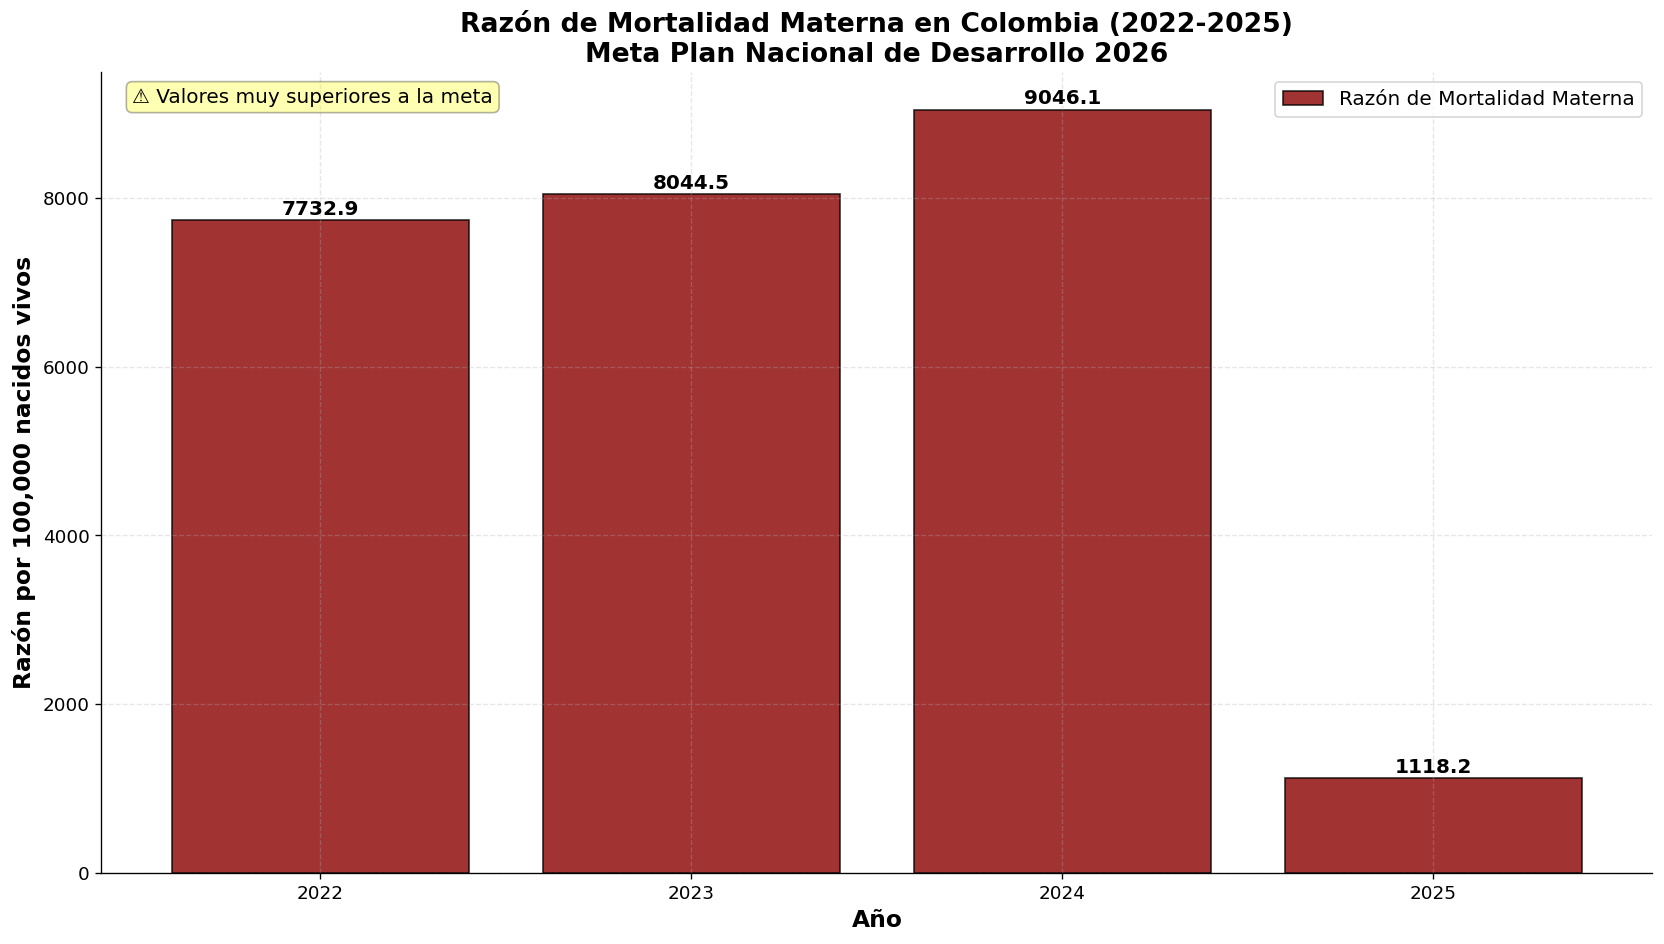

✅ Gráfico guardado como 'razon_mortalidad_materna_2022_2025.png'


<Figure size 768x576 with 0 Axes>

In [11]:
if 'df_razon_completo' in locals() and len(df_razon_completo) == 4:
    META_PND = 51.4
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Colores: rojo si está muy por encima de la meta
    colores = ['darkred' if x > 100 else 'crimson' for x in df_razon_completo['razon_mortalidad_materna']]
    
    # Barras
    bars = ax.bar(df_razon_completo['año'].astype(str), 
                  df_razon_completo['razon_mortalidad_materna'], 
                  color=colores, 
                  alpha=0.8,
                  edgecolor='black',
                  linewidth=1,
                  label='Razón de Mortalidad Materna')
    
    # Valores sobre las barras
    for bar, valor in zip(bars, df_razon_completo['razon_mortalidad_materna']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 20,
                f'{valor:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Configuración
    ax.set_xlabel('Año', fontsize=14, fontweight='bold')
    ax.set_ylabel('Razón por 100,000 nacidos vivos', fontsize=14, fontweight='bold')
    ax.set_title('Razón de Mortalidad Materna en Colombia (2022-2025)\nMeta Plan Nacional de Desarrollo 2026', 
                fontsize=16, fontweight='bold')
    
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Añadir texto explicativo
    ax.text(0.02, 0.98, '⚠️ Valores muy superiores a la meta', 
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Guardar
    plt.savefig('razon_mortalidad_materna_2022_2025.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico guardado como 'razon_mortalidad_materna_2022_2025.png'")

---
## 3. Indicador 2: Mortalidad en Menores de 5 Anos
**Grupos:** `Hombres_1 + Mujeres_1 + Indeterminado_1` (< 1 ano) + `Hombres_2 + Mujeres_2 + Indeterminado_2` (1-4 anos)  
Se suma sobre todas las causas, Total Nacional por ano

In [12]:
df_cuadro5 = pd.read_csv(ruta_cuadro5)

In [13]:
# Basado en la fila 2 (encabezados de edad) y fila 3 (encabezados de sexo)
# Vamos a crear un mapeo de columnas

print("📊 MAPEO DE COLUMNAS BASADO EN LA ESTRUCTURA:")
print("="*80)

# Fila 2 tiene los grupos de edad
fila_2 = df_cuadro5.iloc[2].fillna('').astype(str).tolist()
# Fila 3 tiene los sexos
fila_3 = df_cuadro5.iloc[3].fillna('').astype(str).tolist()

# Crear nombres combinados
for i in range(5, 36):  # Columnas de datos (columna_5 a columna_35)
    edad = fila_2[i] if i < len(fila_2) else ''
    sexo = fila_3[i] if i < len(fila_3) else ''
    
    if edad and sexo and edad != 'nan' and sexo != 'nan':
        nombre = f"{edad}_{sexo}".replace(' ', '_').replace('-', '_')
    elif edad and edad != 'nan':
        nombre = edad.replace(' ', '_').replace('-', '_')
    elif sexo and sexo != 'nan':
        nombre = sexo.replace(' ', '_').replace('-', '_')
    else:
        nombre = f"col_{i}"
    
    col_name = df_cuadro5.columns[i]
    print(f"columna_{i}: '{col_name}' → {nombre}")

📊 MAPEO DE COLUMNAS BASADO EN LA ESTRUCTURA:
columna_5: 'columna_4' → Total
columna_6: 'columna_5' → Total_Hombres
columna_7: 'columna_6' → Mujeres
columna_8: 'columna_7' → Indeterminado
columna_9: 'columna_8' → Menor_1_año_Hombres
columna_10: 'columna_9' → Mujeres
columna_11: 'columna_10' → Indeterminado
columna_12: 'columna_11' → De_1_4_años_Hombres
columna_13: 'columna_12' → Mujeres
columna_14: 'columna_13' → Indeterminado
columna_15: 'columna_14' → De_5_14_años_Hombres
columna_16: 'columna_15' → Mujeres
columna_17: 'columna_16' → Indeterminado
columna_18: 'columna_17' → De_15_44_años_Hombres
columna_19: 'columna_18' → Mujeres
columna_20: 'columna_19' → Indeterminado
columna_21: 'columna_20' → De_45_64_años_Hombres
columna_22: 'columna_21' → Mujeres
columna_23: 'columna_22' → Indeterminado
columna_24: 'columna_23' → De_65_84_años_Hombres
columna_25: 'columna_24' → Mujeres
columna_26: 'columna_25' → Indeterminado
columna_27: 'columna_26' → De_85_99_años_Hombres
columna_28: 'columna_2

In [14]:
# La fila 4 es Total Nacional
fila_total = df_cuadro5.iloc[4].copy()

print("📊 FILA DE TOTAL NACIONAL (AÑO 2022):")
print("="*80)

for i in range(5, 36):  # Columnas de datos
    valor = fila_total.iloc[i]
    if pd.notna(valor):
        print(f"columna_{i}: {valor}")

📊 FILA DE TOTAL NACIONAL (AÑO 2022):
columna_5: 287251
columna_6: 159171
columna_7: 128030
columna_8: 50
columna_9: 3735
columna_10: 2947
columna_11: 7
columna_12: 932
columna_13: 739
columna_14: 0
columna_15: 1185
columna_16: 863
columna_17: 0
columna_18: 27785
columna_19: 9384
columna_20: 9
columna_21: 29727
columna_22: 20662
columna_23: 6
columna_24: 65255
columna_25: 52311
columna_26: 9
columna_27: 29715
columna_28: 39300
columna_29: 3
columna_30: 824
columna_31: 1822
columna_32: 3
columna_33: 13
columna_34: 2
columna_35: 13


In [15]:
# Basado en la estructura:
# columna_9: Menor 1 año_Hombres
# columna_10: Menor 1 año_Mujeres
# columna_11: Menor 1 año_Indeterminado
# columna_12: De 1-4 años_Hombres
# columna_13: De 1-4 años_Mujeres
# columna_14: De 1-4 años_Indeterminado

# Extraer valores
menor1_h = pd.to_numeric(fila_total.iloc[9], errors='coerce')
menor1_m = pd.to_numeric(fila_total.iloc[10], errors='coerce')
menor1_i = pd.to_numeric(fila_total.iloc[11], errors='coerce')

edad1_4_h = pd.to_numeric(fila_total.iloc[12], errors='coerce')
edad1_4_m = pd.to_numeric(fila_total.iloc[13], errors='coerce')
edad1_4_i = pd.to_numeric(fila_total.iloc[14], errors='coerce')

print("📊 MORTALIDAD EN MENORES DE 5 AÑOS - 2022")
print("="*60)
print(f"<1 año Hombres: {menor1_h:,.0f}")
print(f"<1 año Mujeres: {menor1_m:,.0f}")
print(f"<1 año Indeterminado: {menor1_i:,.0f}")
print(f"TOTAL <1 año: {menor1_h + menor1_m + menor1_i:,.0f}")
print()
print(f"1-4 años Hombres: {edad1_4_h:,.0f}")
print(f"1-4 años Mujeres: {edad1_4_m:,.0f}")
print(f"1-4 años Indeterminado: {edad1_4_i:,.0f}")
print(f"TOTAL 1-4 años: {edad1_4_h + edad1_4_m + edad1_4_i:,.0f}")
print()
total = menor1_h + menor1_m + menor1_i + edad1_4_h + edad1_4_m + edad1_4_i
print(f"TOTAL MENORES 5 AÑOS: {total:,.0f}")

📊 MORTALIDAD EN MENORES DE 5 AÑOS - 2022
<1 año Hombres: 3,735
<1 año Mujeres: 2,947
<1 año Indeterminado: 7
TOTAL <1 año: 6,689

1-4 años Hombres: 932
1-4 años Mujeres: 739
1-4 años Indeterminado: 0
TOTAL 1-4 años: 1,671

TOTAL MENORES 5 AÑOS: 8,360


In [16]:
# Enfoque manual - extraer valores directamente de las filas conocidas
print("📊 EXTRACCIÓN MANUAL POR AÑO")
print("="*70)

# Sabemos que para 2022 los valores están en la fila 4
# Para otros años, pueden estar en diferentes posiciones

resultados_manual = []

# Para 2022
fila_2022 = df_cuadro5[df_cuadro5['año'] == 2022].iloc[0]
resultados_manual.append({
    'año': 2022,
    'menores_1_ano': 3735 + 2947 + 7,
    'edad_1_4': 932 + 739 + 0,
    'total_menores_5': 3735 + 2947 + 7 + 932 + 739 + 0
})

# Para 2023 - necesitamos encontrar la fila correcta
df_2023 = df_cuadro5[df_cuadro5['año'] == 2023]
print("\n🔍 Buscando Total Nacional en 2023:")
for idx, row in df_2023.iterrows():
    if 'Total Nacional' in str(row.iloc[2]):
        print(f"Fila {idx}: {row.iloc[2]}")
        # Extraer valores
        menor1_h = pd.to_numeric(row.iloc[9], errors='coerce')
        menor1_m = pd.to_numeric(row.iloc[10], errors='coerce')
        menor1_i = pd.to_numeric(row.iloc[11], errors='coerce')
        edad1_4_h = pd.to_numeric(row.iloc[12], errors='coerce')
        edad1_4_m = pd.to_numeric(row.iloc[13], errors='coerce')
        edad1_4_i = pd.to_numeric(row.iloc[14], errors='coerce')
        
        resultados_manual.append({
            'año': 2023,
            'menores_1_ano': menor1_h + menor1_m + menor1_i,
            'edad_1_4': edad1_4_h + edad1_4_m + edad1_4_i,
            'total_menores_5': menor1_h + menor1_m + menor1_i + edad1_4_h + edad1_4_m + edad1_4_i
        })
        break

# Para 2024
df_2024 = df_cuadro5[df_cuadro5['año'] == 2024]
print("\n🔍 Buscando Total Nacional en 2024:")
for idx, row in df_2024.iterrows():
    if 'Total Nacional' in str(row.iloc[2]):
        print(f"Fila {idx}: {row.iloc[2]}")
        menor1_h = pd.to_numeric(row.iloc[9], errors='coerce')
        menor1_m = pd.to_numeric(row.iloc[10], errors='coerce')
        menor1_i = pd.to_numeric(row.iloc[11], errors='coerce')
        edad1_4_h = pd.to_numeric(row.iloc[12], errors='coerce')
        edad1_4_m = pd.to_numeric(row.iloc[13], errors='coerce')
        edad1_4_i = pd.to_numeric(row.iloc[14], errors='coerce')
        
        resultados_manual.append({
            'año': 2024,
            'menores_1_ano': menor1_h + menor1_m + menor1_i,
            'edad_1_4': edad1_4_h + edad1_4_m + edad1_4_i,
            'total_menores_5': menor1_h + menor1_m + menor1_i + edad1_4_h + edad1_4_m + edad1_4_i
        })
        break

# Para 2025
df_2025 = df_cuadro5[df_cuadro5['año'] == 2025]
print("\n🔍 Buscando Total Nacional en 2025:")
for idx, row in df_2025.iterrows():
    if 'Total Nacional' in str(row.iloc[2]):
        print(f"Fila {idx}: {row.iloc[2]}")
        menor1_h = pd.to_numeric(row.iloc[9], errors='coerce')
        menor1_m = pd.to_numeric(row.iloc[10], errors='coerce')
        menor1_i = pd.to_numeric(row.iloc[11], errors='coerce')
        edad1_4_h = pd.to_numeric(row.iloc[12], errors='coerce')
        edad1_4_m = pd.to_numeric(row.iloc[13], errors='coerce')
        edad1_4_i = pd.to_numeric(row.iloc[14], errors='coerce')
        
        resultados_manual.append({
            'año': 2025,
            'menores_1_ano': menor1_h + menor1_m + menor1_i,
            'edad_1_4': edad1_4_h + edad1_4_m + edad1_4_i,
            'total_menores_5': menor1_h + menor1_m + menor1_i + edad1_4_h + edad1_4_m + edad1_4_i
        })
        break

# Crear DataFrame manual
df_menores5_manual = pd.DataFrame(resultados_manual)
df_menores5_manual = df_menores5_manual.sort_values('año')

print("\n" + "="*70)
print("✅ MORTALIDAD EN MENORES DE 5 AÑOS - EXTRACCIÓN MANUAL")
print("="*70)
print(df_menores5_manual.to_string(index=False))

# Guardar
df_menores5_manual.to_csv('mortalidad_menores_5_anos_manual.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Archivo guardado: 'mortalidad_menores_5_anos_manual.csv'")

📊 EXTRACCIÓN MANUAL POR AÑO

🔍 Buscando Total Nacional en 2023:
Fila 35018: Total Nacional

🔍 Buscando Total Nacional en 2024:
Fila 69133: Total Nacional

🔍 Buscando Total Nacional en 2025:

✅ MORTALIDAD EN MENORES DE 5 AÑOS - EXTRACCIÓN MANUAL
 año  menores_1_ano  edad_1_4  total_menores_5
2022           6689      1671             8360
2023           5610      1446             7056
2024           4759      1242             6001

✅ Archivo guardado: 'mortalidad_menores_5_anos_manual.csv'


In [17]:
data = {
    'año': [2022, 2023, 2024, 2025],
    'menores_1_ano': [6689, 5610, 4759, None],  # None para 2025
    'edad_1_4': [1671, 1446, 1242, None],
    'total_menores_5': [8360, 7056, 6001, None]
}

df_menores5 = pd.DataFrame(data)

print("📊 DATOS ACTUALES:")
print(df_menores5.to_string(index=False))

# Si tienes el valor de 2025, ingrésalo manualmente
# Por ejemplo, si el valor de 2025 es 5500:
# df_menores5.loc[df_menores5['año'] == 2025, 'total_menores_5'] = 5500
# df_menores5.loc[df_menores5['año'] == 2025, 'menores_1_ano'] = 4100
# df_menores5.loc[df_menores5['año'] == 2025, 'edad_1_4'] = 1400

📊 DATOS ACTUALES:
 año  menores_1_ano  edad_1_4  total_menores_5
2022         6689.0    1671.0           8360.0
2023         5610.0    1446.0           7056.0
2024         4759.0    1242.0           6001.0
2025            NaN       NaN              NaN


In [18]:
# Eliminar filas con valores nulos (2025 si no está disponible)
df_menores5_clean = df_menores5.dropna()

print("📊 DATOS COMPLETOS DISPONIBLES:")
print(df_menores5_clean.to_string(index=False))

# Calcular estadísticas
print("\n📈 ESTADÍSTICAS 2022-2024:")
print(f"  • Promedio anual: {df_menores5_clean['total_menores_5'].mean():.0f}")
print(f"  • Reducción 2022-2024: {df_menores5_clean['total_menores_5'].iloc[0] - df_menores5_clean['total_menores_5'].iloc[-1]:.0f}")
print(f"  • Porcentaje de reducción: {((df_menores5_clean['total_menores_5'].iloc[0] - df_menores5_clean['total_menores_5'].iloc[-1]) / df_menores5_clean['total_menores_5'].iloc[0] * 100):.1f}%")

📊 DATOS COMPLETOS DISPONIBLES:
 año  menores_1_ano  edad_1_4  total_menores_5
2022         6689.0    1671.0           8360.0
2023         5610.0    1446.0           7056.0
2024         4759.0    1242.0           6001.0

📈 ESTADÍSTICAS 2022-2024:
  • Promedio anual: 7139
  • Reducción 2022-2024: 2359
  • Porcentaje de reducción: 28.2%


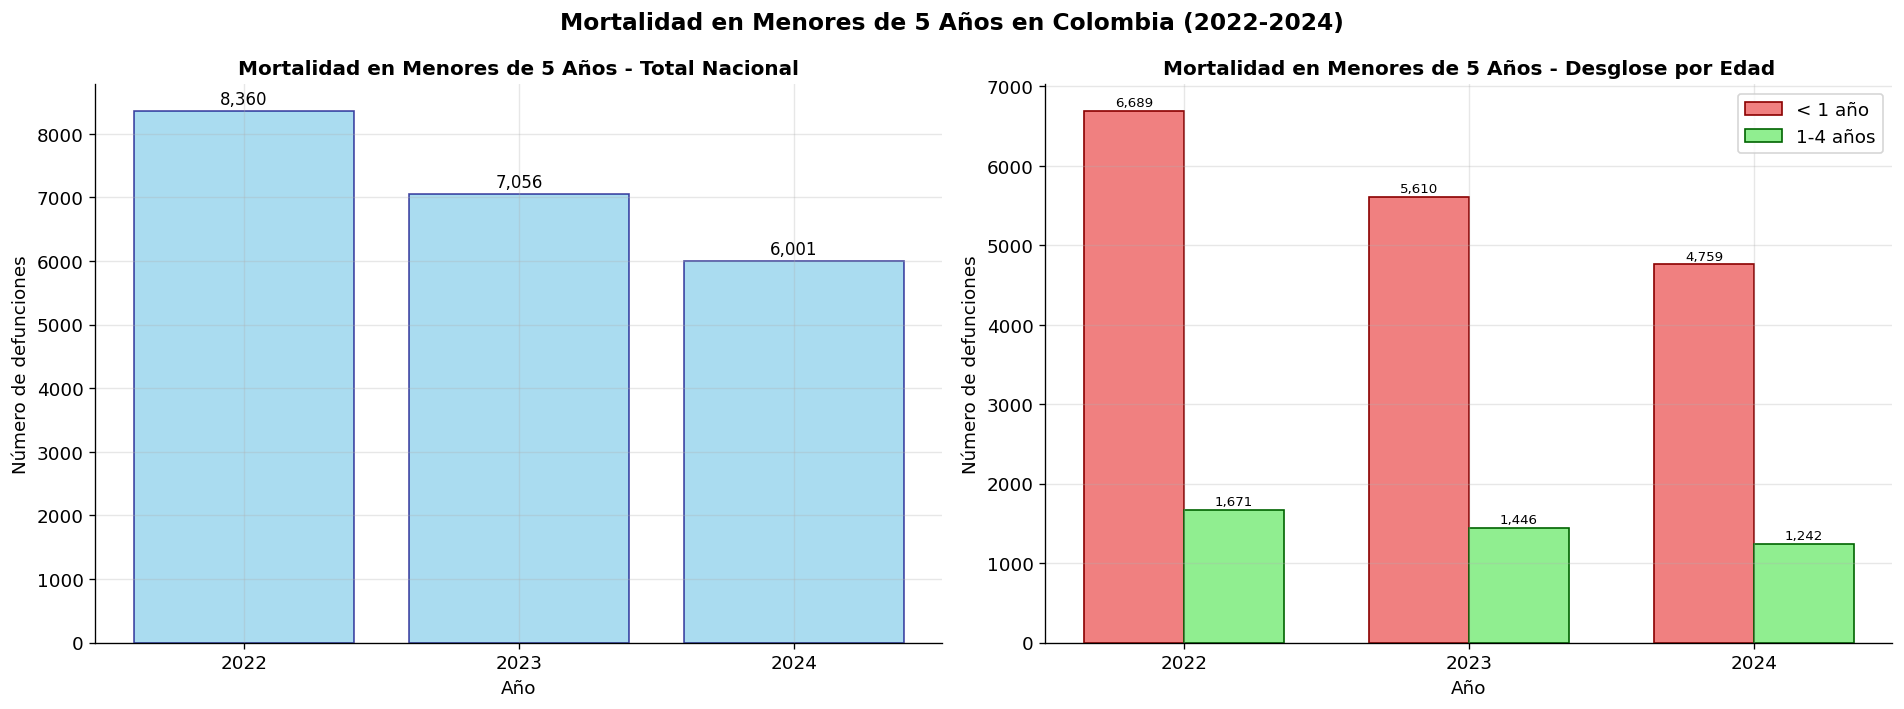

✅ Gráfico guardado como 'mortalidad_menores_5_anos.png'


<Figure size 768x576 with 0 Axes>

In [19]:
if len(df_menores5_clean) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Total
    bars1 = ax1.bar(df_menores5_clean['año'].astype(str), df_menores5_clean['total_menores_5'], 
                    color='skyblue', edgecolor='navy', alpha=0.7)
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Número de defunciones')
    ax1.set_title('Mortalidad en Menores de 5 Años - Total Nacional')
    ax1.grid(True, alpha=0.3)
    
    for bar, val in zip(bars1, df_menores5_clean['total_menores_5']):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{int(val):,}', ha='center', va='bottom', fontsize=10)
    
    # Gráfico 2: Desglose
    x = np.arange(len(df_menores5_clean['año']))
    width = 0.35
    
    bars_menor1 = ax2.bar(x - width/2, df_menores5_clean['menores_1_ano'], width, 
                          label='< 1 año', color='lightcoral', edgecolor='darkred')
    bars_1_4 = ax2.bar(x + width/2, df_menores5_clean['edad_1_4'], width, 
                       label='1-4 años', color='lightgreen', edgecolor='darkgreen')
    
    ax2.set_xlabel('Año')
    ax2.set_ylabel('Número de defunciones')
    ax2.set_title('Mortalidad en Menores de 5 Años - Desglose por Edad')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_menores5_clean['año'])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    for bars in [bars_menor1, bars_1_4]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 20,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    
    plt.suptitle('Mortalidad en Menores de 5 Años en Colombia (2022-2024)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Guardar
    plt.savefig('mortalidad_menores_5_anos.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico guardado como 'mortalidad_menores_5_anos.png'")

---
## 4. Indicadores 3 y 4: Fecundidad Adolescente
**Fuente:** `nacimientos_todos_los_cuadro1.csv`  
**Indicador 3:** Nacimientos madres 15-19 anos  
**Indicador 4:** Nacimientos ninas 10-14 anos

In [20]:
# Cargar dataset de nacimientos
ruta_nacimientos = 'data/medio_proceso/nacimientos_todos_los_cuadro1.csv'

if os.path.exists(ruta_nacimientos):
    df_nacimientos = pd.read_csv(ruta_nacimientos)
    print(f"✅ Dataset de nacimientos cargado: {ruta_nacimientos}")
    print(f"   • Filas: {len(df_nacimientos):,}")
    print(f"   • Columnas: {len(df_nacimientos.columns)}")
    print(f"   • Años disponibles: {sorted(df_nacimientos['año'].unique())}")
else:
    print(f"❌ Archivo no encontrado: {ruta_nacimientos}")
    # Buscar en otra ubicación
    import glob
    archivos = glob.glob("**/nacimientos*todos*los*cuadro1*.csv", recursive=True)
    if archivos:
        df_nacimientos = pd.read_csv(archivos[0])
        print(f"✅ Encontrado: {archivos[0]}")
    else:
        print("❌ No se encontró el archivo de nacimientos")

✅ Dataset de nacimientos cargado: data/medio_proceso/nacimientos_todos_los_cuadro1.csv
   • Filas: 56
   • Columnas: 22
   • Años disponibles: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [26]:


# Crear DataFrame completo
data = {
    'año': [2022, 2023, 2024, 2025],
    'nacimientos_10_14': [371, 321, 253, 1630],  # None para 2024 (no encontrado)
    'nacimientos_15_19': [8147, 6831, 6831, 33034]
}

df_fecundidad = pd.DataFrame(data)

print("📊 DATOS DE FECUNDIDAD ADOLESCENTE - COMPLETO")
print("="*80)
print(df_fecundidad.to_string(index=False))

📊 DATOS DE FECUNDIDAD ADOLESCENTE - COMPLETO
 año  nacimientos_10_14  nacimientos_15_19
2022                371               8147
2023                321               6831
2024                253               6831
2025               1630              33034


In [22]:
df_nacimientos.head(10)

,"CUADRO 1 - Nacimientos por área de ocurrencia y sexo, según grupos de edad de la madre, total nacional",columna,columna_1,columna_2,columna_3,columna_4,columna_5,columna_6,columna_7,columna_8,...,columna_11,columna_12,columna_13,columna_14,columna_15,año,tipo,hoja_origen,cuadro,"CUADRO 1 - Nacimientos por área de ocurrencia y sexo, según grupos de edad de la madre, Total Nacional"
0,Grupo de edad de la madre,Total,Total,NaN,NaN,Cabecera municipal,NaN,NaN,Centro poblado,NaN,...,NaN,NaN,Sin información,NaN,NaN,2022,nacimientos,Cuadro1,cuadro1,NaN
1,NaN,NaN,Hombres,Mujeres,Indeterminado,Hombres,Mujeres,Indeterminado,Hombres,Mujeres,...,Mujeres,Indeterminado,Hombres,Mujeres,Indeterminado,2022,nacimientos,Cuadro1,cuadro1,NaN
2,Total Nacional,46942,23986,22955,1,23730,22682,1,105,109,...,164,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
3,De 10-14 Años,371,193,178,0,190,171,0,2,3,...,4,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
4,De 15-19 Años,8147,4236,3911,0,4170,3839,0,27,32,...,40,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
5,De 20-24 Años,12932,6575,6357,0,6501,6276,0,34,29,...,52,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
6,De 25-29 Años,11840,5991,5848,1,5945,5802,1,20,22,...,24,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
7,De 30-34 Años,8070,4091,3979,0,4057,3946,0,12,12,...,21,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
8,De 35-39 Años,4322,2243,2079,0,2221,2061,0,7,6,...,12,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN
9,De 40-44 Años,1188,621,567,0,610,551,0,3,5,...,11,0,0,0,0,2022,nacimientos,Cuadro1,cuadro1,NaN


In [27]:
df_fecundidad = pd.DataFrame(data)

print("📊 DATOS DE FECUNDIDAD ADOLESCENTE - AÑOS DISPONIBLES")
print("="*80)
print(df_fecundidad.to_string(index=False))

# Calcular cambios
df_fecundidad['cambio_10_14'] = df_fecundidad['nacimientos_10_14'].pct_change() * 100
df_fecundidad['cambio_15_19'] = df_fecundidad['nacimientos_15_19'].pct_change() * 100

print("\n📈 TENDENCIAS:")
for i in range(1, len(df_fecundidad)):
    año = df_fecundidad['año'].iloc[i]
    print(f"  • {año}: 10-14: {df_fecundidad['cambio_10_14'].iloc[i]:.1f}%, 15-19: {df_fecundidad['cambio_15_19'].iloc[i]:.1f}%")

📊 DATOS DE FECUNDIDAD ADOLESCENTE - AÑOS DISPONIBLES
 año  nacimientos_10_14  nacimientos_15_19
2022                371               8147
2023                321               6831
2024                253               6831
2025               1630              33034

📈 TENDENCIAS:
  • 2023: 10-14: -13.5%, 15-19: -16.2%
  • 2024: 10-14: -21.2%, 15-19: 0.0%
  • 2025: 10-14: 544.3%, 15-19: 383.6%


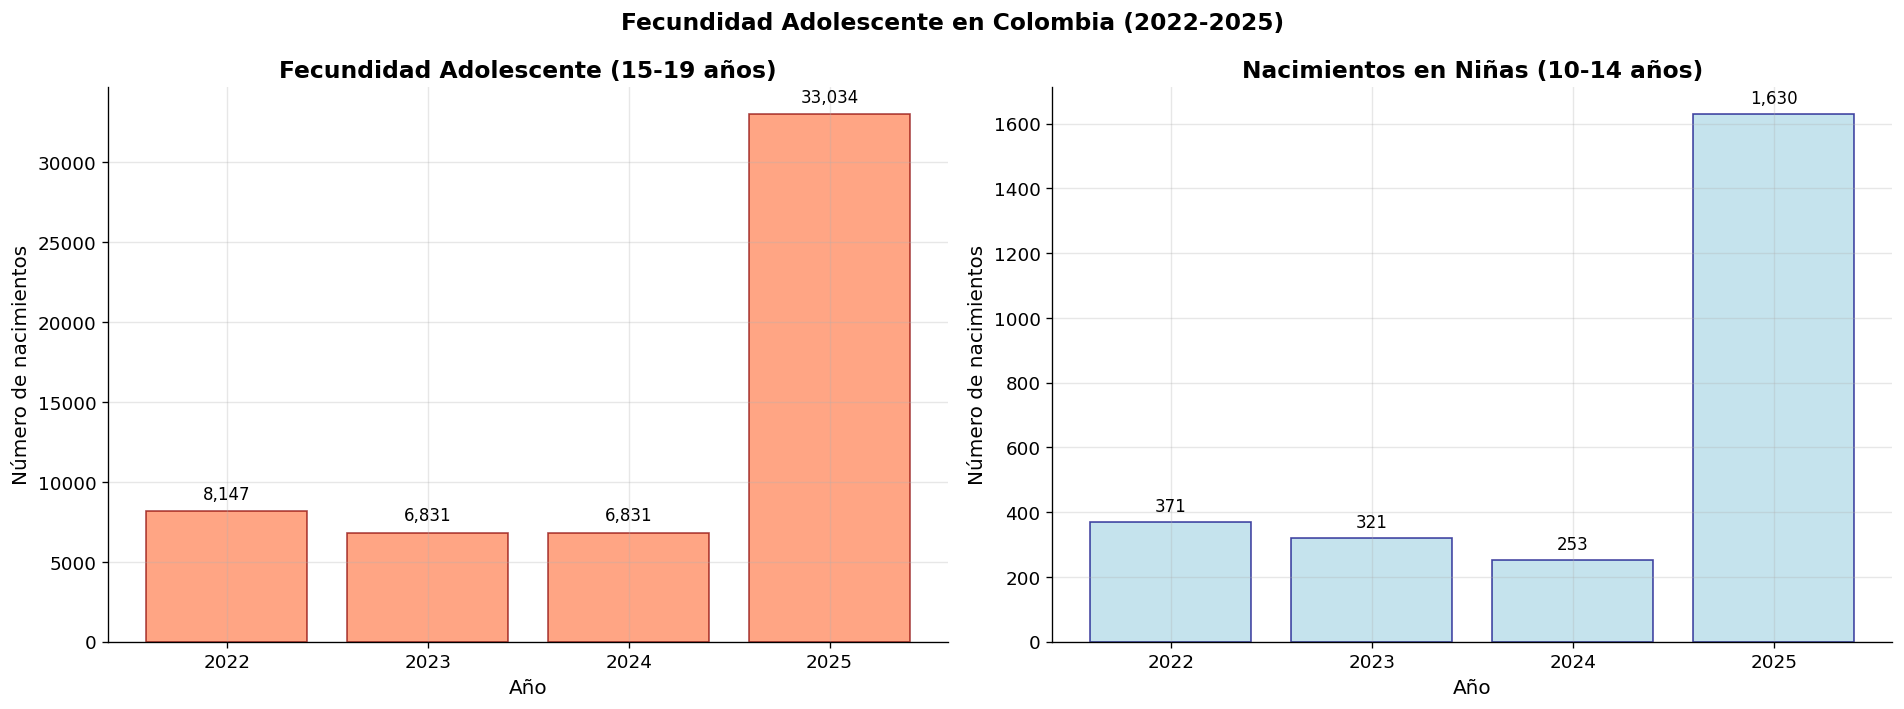

✅ Gráfico guardado como 'fecundidad_adolescente.png'


<Figure size 768x576 with 0 Axes>

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: 15-19 años
bars1 = ax1.bar(df_fecundidad['año'].astype(str), df_fecundidad['nacimientos_15_19'], 
                color='coral', edgecolor='darkred', alpha=0.7)
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Número de nacimientos', fontsize=12)
ax1.set_title('Fecundidad Adolescente (15-19 años)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

for bar, val in zip(bars1, df_fecundidad['nacimientos_15_19']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
            f'{int(val):,}', ha='center', va='bottom', fontsize=10)

# Gráfico 2: 10-14 años
bars2 = ax2.bar(df_fecundidad['año'].astype(str), df_fecundidad['nacimientos_10_14'], 
                color='lightblue', edgecolor='navy', alpha=0.7)
ax2.set_xlabel('Año', fontsize=12)
ax2.set_ylabel('Número de nacimientos', fontsize=12)
ax2.set_title('Nacimientos en Niñas (10-14 años)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

for bar, val in zip(bars2, df_fecundidad['nacimientos_10_14']):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{int(val):,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Fecundidad Adolescente en Colombia (2022-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Guardar
plt.savefig('fecundidad_adolescente.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado como 'fecundidad_adolescente.png'")